In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split 
from torch import nn
import torch
import random

In [2]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

out = np.load('training-val-test-data.npz')
th_train = out['th'] #th[0],th[1],th[2],th[3],...
u_train = out['u'] #u[0],u[1],u[2],u[3],...

# data = np.load('test-prediction-submission-file.npz')
data = np.load('hidden-test-prediction-submission-file.npz')
upast_test = data['upast'] #N by u[k-15],u[k-14],...,u[k-1]
thpast_test = data['thpast'] #N by y[k-15],y[k-14],...,y[k-1]
# thpred = data['thnow'] #all zeros

In [3]:
def create_IO_data(u,y,na,nb):
    X = []
    Y = []
    for k in range(max(na,nb), len(y)):
        u_past = u[k-nb:k]
        y_past = y[k-na:k]

        # Trigonometric features of the raw angles
        sin_y = np.sin(y_past)
        cos_y = np.cos(y_past)
        
        X.append(np.concatenate([u_past,sin_y, cos_y]))
        Y.append(y[k])
    return np.array(X), np.array(Y)

In [4]:
na = 15
nb = 15
u_tr, u_val, th_tr, th_val = train_test_split(u_train, th_train, shuffle = False)

Xtrain_u, Ytrain_u = create_IO_data(u_tr, th_tr, na, nb)
Xval_u, Yval_u = create_IO_data(u_val, th_val, na, nb)

# Scaling of variables
X_mean = np.mean(Xtrain_u, axis = 0)
X_std = np.std(Xtrain_u, axis = 0)

Y_mean = float(np.mean(Ytrain_u))
Y_std = float(np.std(Ytrain_u))

Xtrain = (Xtrain_u - X_mean)/X_std
Xval = (Xval_u - X_mean)/X_std

Ytrain = (Ytrain_u - Y_mean)/Y_std
Yval = (Yval_u - Y_mean)/Y_std

In [5]:
def simulation_IO_model(f, ulist, ylist, skip=50):

    upast = ulist[skip-nb:skip].tolist() #good initialization
    ypast = ylist[skip-na:skip].tolist()
    Y = ylist[:skip].tolist()
    
    for u in ulist[skip:]:
        u_p = np.array(upast)
        y_p = np.array(ypast)
        
        x = np.concatenate([u_p ,np.sin(y_p), np.cos(y_p)],axis=0)
        ypred = f(x)
        Y.append(ypred)
        upast.append(u)
        upast.pop(0)
        ypast.append(ypred)
        ypast.pop(0)
    return np.array(Y)

In [6]:
class Network(nn.Module): 
    def __init__(self, n_in, n_hidden_nodes): 
        super(Network,self).__init__()
        self.lay1 = nn.Linear(n_in, n_hidden_nodes).double()
        self.lay2 = nn.Linear(n_hidden_nodes, n_hidden_nodes).double()
        self.lay3 = nn.Linear(n_hidden_nodes, n_hidden_nodes).double()
        self.lay4 = nn.Linear(n_hidden_nodes, n_hidden_nodes).double()
        self.lay5 = nn.Linear(n_hidden_nodes, 1).double()

    def forward(self,u): 
        # u.shape == (N,10)
        #u = u[:, None]  # Convert u from shape (N,) to (N,1)
        x1 = torch.nn.functional.elu(self.lay1(u)) 
        x2 = torch.nn.functional.elu(self.lay2(x1))
        x3 = torch.nn.functional.elu(self.lay2(x2))
        x4 = torch.nn.functional.elu(self.lay2(x3))
        y = self.lay3(x4)[:, 0] 

        return y

n_hidden_nodes = 64
epochs = 5000 

In [7]:
model = Network(Xtrain.shape[1],n_hidden_nodes) #create the network
    
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3, weight_decay = 1e-5)

Xtrain,Ytrain, Xval, Yval = [torch.as_tensor(x) for x in [Xtrain,Ytrain, Xval, Yval]]

best_val_loss = float('inf')
best_weights = None

for epoch in range(epochs):
    Loss = torch.mean((model(Xtrain)-Ytrain)**2)
    optimizer.zero_grad() #set the gradient buffers to zero, this is essential.
    Loss.backward()
    optimizer.step()
    
    if epoch%100==0: 
        model.eval()
        with torch.no_grad():
            val_loss = torch.mean((model(Xval) - Yval)**2).item()**0.5
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict()
        
        print(epoch,Loss.item()**0.5)

# Restore the absolute best parameter state found during validation tracking
model.load_state_dict(best_weights)
model.eval()

skip = max(na,nb)
th_train_sim = simulation_IO_model(lambda x: (model(torch.as_tensor((x - X_mean) / X_std).unsqueeze(0).double()).item() * Y_std) + Y_mean, u_train, th_train, skip=skip)
print('train simulation errors:')
print('RMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5,'radians')
print('RMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5/(2*np.pi)*360,'degrees')
print('NRMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5/th_train.std()*100,'%')


skip = 50
th_test_sim = simulation_IO_model(
    lambda x: (model(torch.as_tensor((x - X_mean) / X_std).unsqueeze(0).double()).item() * Y_std) + Y_mean, 
    upast_test, 
    thpast_test, 
    skip=50
)

assert len(th_test_sim)==len(th_test)
np.savez('hidden-test-simulation-example-submission-file.npz', th=thpast_test_sim, u=upast_test)

0 0.9847216399556361
100 0.07461084879649464
200 0.04873350114350319
300 0.037811769276775674
400 0.03175926292709643
500 0.027741898158453845
600 0.024729583662903964
700 0.022313581914065145
800 0.02031188163617433
900 0.018618328660934973
1000 0.017179138500021805
1100 0.01597036737938596
1200 0.014970059886542375
1300 0.01414668259355044
1400 0.013457510710229935
1500 0.01286588032115418
1600 0.012345614611467185
1700 0.01192532733736944
1800 0.011523417311032564
1900 0.011206376534823929
2000 0.01088215288415012
2100 0.015389427808243459
2200 0.0103675787190528
2300 0.010111200805470006
2400 0.010013325698147129
2500 0.009728087310944964
2600 0.009517757921051678
2700 0.009473397078686129
2800 0.009240761752833847
2900 0.00906268137151945
3000 0.011638827172331405
3100 0.008892896838103992
3200 0.008724210591726065
3300 0.010003815440021682
3400 0.008501931719270587
3500 0.008368290590497192
3600 0.00842487140615863
3700 0.012876696316673604
3800 0.016693923656470513
3900 0.008052

ValueError: operands could not be broadcast together with shapes (45,15) (45,) 

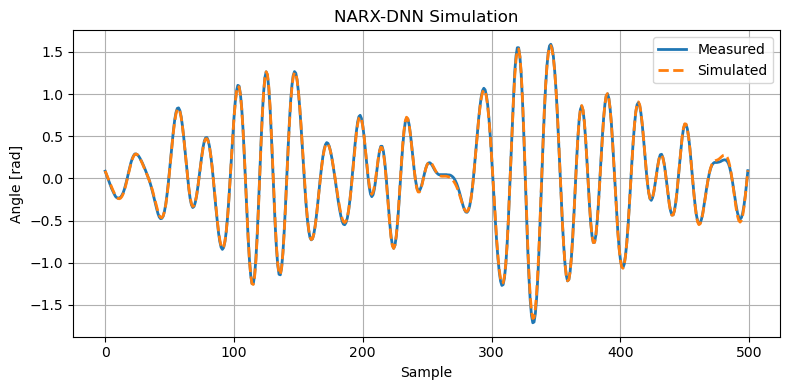

In [12]:
plt.figure(figsize=(8,4))

start = 1000
end = 1500

plt.plot(th_train[start:end], linewidth=2, label='Measured')
plt.plot(th_train_sim[start:end], '--', linewidth=2, label='Simulated')

plt.xlabel('Sample')
plt.ylabel('Angle [rad]')
plt.title('NARX-DNN Simulation')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('ANN_simulation_fit.png', dpi=300, bbox_inches='tight')
plt.show()

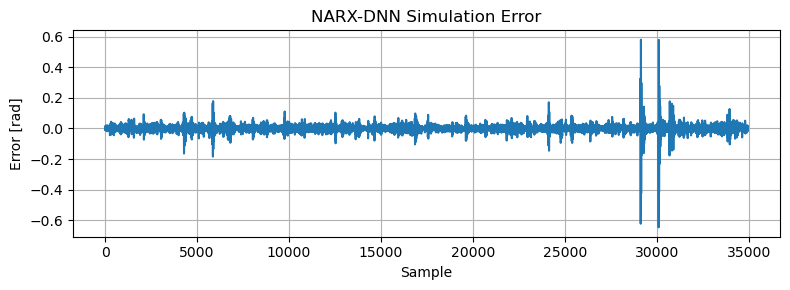

In [13]:
error = th_train_sim[skip:] - th_train[skip:]

plt.figure(figsize=(8,3))

plt.plot(error)

plt.xlabel('Sample')
plt.ylabel('Error [rad]')
plt.title('NARX-DNN Simulation Error')
plt.grid(True)

plt.tight_layout()
plt.savefig('ANN_simulation_error.png', dpi=300, bbox_inches='tight')
plt.show()

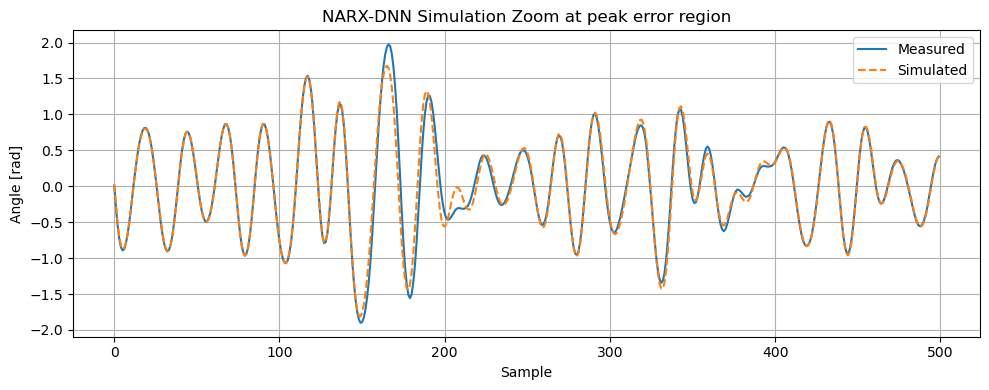

In [23]:
start = 29000
end = 29500

plt.figure(figsize=(10,4))
plt.plot(th_train[start:end], label='Measured')
plt.plot(th_train_sim[start:end], '--', label='Simulated')
plt.xlabel('Sample')
plt.ylabel('Angle [rad]')
plt.title('NARX-DNN Simulation Zoom at peak error region')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('ANN_simulation_zoom.png', dpi=300, bbox_inches='tight')
plt.show()